<a href="https://colab.research.google.com/github/teodoraztodorovic/PDU/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Semantička segmentacija mamografskih slika
na osnovu recepta datog na https://github.com/qubvel-org/
segmentation_models.pytorch (UNet++)

In [1]:
!pip install -q pydicom segmentation-models-pytorch pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg albumentations optuna

In [2]:
import os
import json
import zipfile
import plistlib
import random
from collections import Counter
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import pydicom
import albumentations as A
import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
import torch.nn.functional as F


import optuna

from google.colab import drive

## Reproducibilnost

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

## Učitavanje dataseta

In [4]:
drive.mount('/content/drive')

project_dir = '/content/drive/MyDrive/PDU'
dataset_zip = f'{project_dir}/INBreast.zip'
extract_dir = '/content/INBreast'

with zipfile.ZipFile(dataset_zip, 'r') as zip_file:
    zip_file.extractall(extract_dir)

annotations_dir = os.path.join(extract_dir, 'INBreast/AllXML')
dicom_dir = os.path.join(extract_dir, 'INBreast/AllDICOMs')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Izvlačenje anotacija masa


In [5]:
def extract_mass_polygons(xml_path):
    with open(xml_path, 'rb') as f:
        annotation = plistlib.load(f)

    rois = annotation['Images'][0]['ROIs']
    return [
        [eval(point) for point in roi['Point_px']]
        for roi in rois if roi.get('Name') == 'Mass'
    ]


def mass_polygons_to_mask(polygons, shape):
    mask = np.zeros(shape, dtype=np.uint8)
    for polygon in polygons:
        points = np.array(polygon, dtype=np.int32)
        cv2.fillPoly(mask, [points], 1)
    return mask

In [6]:
mass_counts = {}
for filename in os.listdir(annotations_dir):
    if not filename.endswith('.xml'):
        continue
    polygons = extract_mass_polygons(os.path.join(annotations_dir, filename))
    mass_counts[filename] = len(polygons)

case_ids = [name.replace('.xml', '') for name, count in mass_counts.items() if count > 0]
print(f'Slučajevi sa bar jednom masom: {len(case_ids)} od {len(mass_counts)} ukupno')

Slučajevi sa bar jednom masom: 107 od 343 ukupno


## Povezivanje slučajeva sa DICOM slikama

In [7]:
case_to_dicom_file = {}
for filename in os.listdir(dicom_dir):
    case_id = filename.split('_')[0]
    if case_id in case_ids:
        case_to_dicom_file[case_id] = filename

missing = set(case_ids) - case_to_dicom_file.keys()
print(f'Pronađen DICOM fajl za {len(case_to_dicom_file)} slučajeva, nedostaje {len(missing)}')

Pronađen DICOM fajl za 107 slučajeva, nedostaje 0


## Grupisanje po pacijentu


In [8]:
case_to_patient = {
    case_id: filename.split('_')[1]
    for case_id, filename in case_to_dicom_file.items()
}

patient_ids = [case_to_patient[cid] for cid in case_ids]
case_ids_arr = np.array(case_ids)
patient_ids_arr = np.array(patient_ids)

n_unique_patients = len(set(patient_ids))
counts = Counter(patient_ids)
multi = {p: c for p, c in counts.items() if c > 1}
print(f'{len(case_ids)} slučajeva pripada {n_unique_patients} jedinstvenih pacijenata')
print(f'Pacijenata sa >1 slikom-sa-masom: {len(multi)}')

107 slučajeva pripada 50 jedinstvenih pacijenata
Pacijenata sa >1 slikom-sa-masom: 48


## Učitavanje slike sa maskom

In [9]:
def crop_breast_region(image, mask, margin_ratio=0.02):
    img_uint8 = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image, mask

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    margin = int(margin_ratio * max(image.shape))
    x0, y0 = max(x - margin, 0), max(y - margin, 0)
    x1, y1 = min(x + w + margin, image.shape[1]), min(y + h + margin, image.shape[0])

    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def load_case(case_id):
    dicom_path = os.path.join(dicom_dir, case_to_dicom_file[case_id])
    dicom_file = pydicom.dcmread(dicom_path)
    image = dicom_file.pixel_array.astype(np.float32)

    if getattr(dicom_file, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        image = image.max() - image

    xml_path = os.path.join(annotations_dir, case_id + '.xml')
    polygons = extract_mass_polygons(xml_path)
    mask = mass_polygons_to_mask(polygons, image.shape)

    image, mask = crop_breast_region(image, mask)

    p_low, p_high = np.percentile(image, [1, 99])
    image = np.clip(image, p_low, p_high)
    image = (image - p_low) / (p_high - p_low + 1e-7)

    return image, mask

## Kreiranje dataseta

In [10]:
image_size = 512
image_cache = {}

for case_id in case_ids:
    image, mask = load_case(case_id)
    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    image_cache[case_id] = (image.astype(np.float32), mask.astype(np.uint8))

print(f'Keširano {len(image_cache)} slika')

Keširano 107 slika


In [11]:
class BreastMassDataset(Dataset):
    def __init__(self, case_ids, cache, transform=None):
        self.case_ids = case_ids
        self.cache = cache
        self.transform = transform

    def __len__(self):
        return len(self.case_ids)

    def __getitem__(self, idx):
        case_id = self.case_ids[idx]
        image, mask = self.cache[case_id]

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        image_tensor = torch.from_numpy(image).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
        return image_tensor, mask_tensor

In [12]:
def build_augmentation(use_elastic):
    base = [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
    ]
    if use_elastic:
        base += [
            A.ElasticTransform(alpha=40, sigma=6, p=0.3),
            A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
        ]
    return A.Compose(base)

##UNet++


In [13]:
def build_model():
    model = smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights=None,
        in_channels=1,
        classes=1,
        activation=None,
    )

    pretrained_resnet = tv_models.resnet34(weights=tv_models.ResNet34_Weights.IMAGENET1K_V1)
    pretrained_state = pretrained_resnet.state_dict()

    encoder_state = model.encoder.state_dict()
    matched_state = {}
    for key in encoder_state:
        if key in pretrained_state and pretrained_state[key].shape == encoder_state[key].shape:
            matched_state[key] = pretrained_state[key]

    first_conv_key = 'conv1.weight'
    if first_conv_key in pretrained_state:
        rgb_weights = pretrained_state[first_conv_key]
        matched_state[first_conv_key] = rgb_weights.mean(dim=1, keepdim=True)

    model.encoder.load_state_dict(matched_state, strict=False)
    return model

## Metrike i loss

In [14]:
def compute_metrics(pred_logits, target):
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred_mask, target.long(), mode='binary')
    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro-imagewise')
    dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro-imagewise')
    return iou.item(), dice.item()


def build_loss_from_config(config):
    if config['loss_type'] == 'dice_bce':
        dice_l = smp.losses.DiceLoss(mode='binary', from_logits=True)
        bce_l = nn.BCEWithLogitsLoss()
        bce_weight = config['bce_weight']

        def loss_function(logits, target):
            return (1 - bce_weight) * dice_l(logits, target) + bce_weight * bce_l(logits, target)

        return loss_function
    else:
        return smp.losses.DiceLoss(mode='binary', from_logits=True)

## Trening/validaciona petlja za jednu epohu

In [15]:
def run_epoch(model, loader, optimizer, device, loss_function, train=True):
    model.train() if train else model.eval()
    total_loss, total_iou, total_dice, n_batches = 0, 0, 0, 0

    with torch.set_grad_enabled(train):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            if train:
                optimizer.zero_grad()

            logits = model(images)
            loss = loss_function(logits, masks)

            if train:
                loss.backward()
                optimizer.step()

            iou, dice = compute_metrics(logits, masks)
            total_loss += loss.item()
            total_iou += iou
            total_dice += dice
            n_batches += 1

    return total_loss / n_batches, total_iou / n_batches, total_dice / n_batches

## Pretraga hiperparametara (Optuna)


In [16]:
batch_size = 8
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(case_ids_arr, groups=patient_ids_arr))

train_ids_single = case_ids_arr[train_idx].tolist()
val_ids_single = case_ids_arr[val_idx].tolist()
print(f'train: {len(train_ids_single)} | val: {len(val_ids_single)}')

val_loader_single = DataLoader(
    BreastMassDataset(val_ids_single, image_cache, transform=None),
    batch_size=batch_size, shuffle=False
)

device: cuda
train: 86 | val: 21


In [17]:
def objective(trial):

    loss_type = trial.suggest_categorical('loss_type', ['dice', 'dice_bce'])
    use_elastic = trial.suggest_categorical('use_elastic', [True, False])
    lr = trial.suggest_float('lr', 5e-5, 2e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)

    config = {'loss_type': loss_type}
    if loss_type == 'dice_bce':
        config['bce_weight'] = trial.suggest_float('bce_weight', 0.10, 0.30)
    loss_function = build_loss_from_config(config)

    set_seed(SEED)
    transform = build_augmentation(use_elastic)

    train_loader = DataLoader(
        BreastMassDataset(train_ids_single, image_cache, transform=transform),
        batch_size=batch_size, shuffle=True
    )

    model = build_model().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    best_val_dice = 0.0
    n_trial_epochs = 30

    for epoch in range(n_trial_epochs):
        run_epoch(model, train_loader, optimizer, device, loss_function, train=True)
        _, _, val_dice = run_epoch(model, val_loader_single, optimizer, device, loss_function, train=False)

        scheduler.step(val_dice)
        best_val_dice = max(best_val_dice, val_dice)

        trial.report(val_dice, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_dice

In [18]:
best_params_path = f'{project_dir}/best_params.json'

if os.path.exists(best_params_path):
    print('best_params.json već postoji - Optuna pretraga se NE pokreće ponovo.')
    print('(obriši fajl na Driveu da ponoviš pretragu)')
else:
    study = optuna.create_study(
        direction='maximize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    study.optimize(objective, n_trials=20)

    with open(best_params_path, 'w') as f:
        json.dump(study.best_params, f)

    print('Najbolji val Dice:', study.best_value)
    print('Najbolji parametri (sačuvani na Drive):')
    for key, value in study.best_params.items():
        print(f'  {key}: {value}')

best_params.json već postoji - Optuna pretraga se NE pokreće ponovo.
(obriši fajl na Driveu da ponoviš pretragu)


## Finalna konfiguracija


In [19]:
with open(best_params_path) as f:
    loaded_params = json.load(f)

best_config = {'loss_type': loaded_params['loss_type']}
if best_config['loss_type'] == 'dice_bce':
    best_config['bce_weight'] = loaded_params['bce_weight']

best_lr = loaded_params['lr']
best_weight_decay = loaded_params['weight_decay']
best_use_elastic = loaded_params['use_elastic']

print('Finalna konfiguracija:')
print(f'  loss: {best_config}')
print(f'  lr: {best_lr:.2e}')
print(f'  weight_decay: {best_weight_decay:.2e}')
print(f'  augmentacija (elastic/grid): {best_use_elastic}')

Finalna konfiguracija:
  loss: {'loss_type': 'dice_bce', 'bce_weight': 0.11535210509470156}
  lr: 1.21e-04
  weight_decay: 1.70e-04
  augmentacija (elastic/grid): True


epoha   1 | train_loss=0.901 train_dice=0.089 | val_loss=0.903 val_dice=0.113
epoha  10 | train_loss=0.744 train_dice=0.512 | val_loss=0.724 val_dice=0.568
epoha  20 | train_loss=0.595 train_dice=0.646 | val_loss=0.651 val_dice=0.481
epoha  30 | train_loss=0.484 train_dice=0.735 | val_loss=0.518 val_dice=0.662
epoha  40 | train_loss=0.444 train_dice=0.743 | val_loss=0.530 val_dice=0.619
epoha  50 | train_loss=0.414 train_dice=0.803 | val_loss=0.499 val_dice=0.662
epoha  60 | train_loss=0.416 train_dice=0.781 | val_loss=0.490 val_dice=0.673
epoha  70 | train_loss=0.425 train_dice=0.808 | val_loss=0.489 val_dice=0.674
epoha  80 | train_loss=0.426 train_dice=0.795 | val_loss=0.493 val_dice=0.663

Najbolji val dice: 0.677 na epohi 66


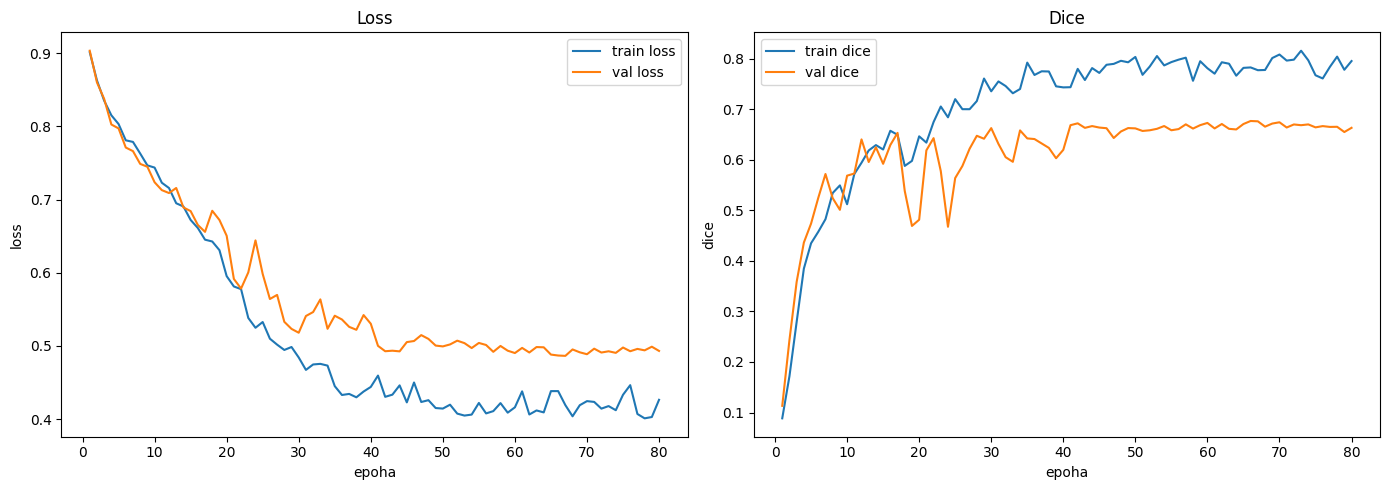

In [20]:
CHECK_EPOCHS = 80

set_seed(SEED)
overfit_transform = build_augmentation(best_use_elastic)
overfit_loss_function = build_loss_from_config(best_config)

overfit_train_loader = DataLoader(
    BreastMassDataset(train_ids_single, image_cache, transform=overfit_transform),
    batch_size=batch_size, shuffle=True
)

overfit_model = build_model().to(device)
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
overfit_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    overfit_optimizer, mode='max', factor=0.5, patience=4
)

history = {'epoch': [], 'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': []}

for epoch in range(1, CHECK_EPOCHS + 1):
    train_loss, _, train_dice = run_epoch(
        overfit_model, overfit_train_loader, overfit_optimizer, device, overfit_loss_function, train=True
    )
    val_loss, _, val_dice = run_epoch(
        overfit_model, val_loader_single, overfit_optimizer, device, overfit_loss_function, train=False
    )
    overfit_scheduler.step(val_dice)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoha {epoch:3d} | train_loss={train_loss:.3f} train_dice={train_dice:.3f} '
              f'| val_loss={val_loss:.3f} val_dice={val_dice:.3f}')

best_val_epoch = int(np.argmax(history['val_dice'])) + 1
print(f'\nNajbolji val dice: {max(history["val_dice"]):.3f} na epohi {best_val_epoch}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='train loss')
axes[0].plot(history['epoch'], history['val_loss'], label='val loss')
axes[0].set_xlabel('epoha'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(history['epoch'], history['train_dice'], label='train dice')
axes[1].plot(history['epoch'], history['val_dice'], label='val dice')
axes[1].set_xlabel('epoha'); axes[1].set_ylabel('dice'); axes[1].legend(); axes[1].set_title('Dice')

plt.tight_layout()
plt.show()

## Leave-One-Patient-Out evaluacija

In [21]:
LOPO_EPOCHS = 50
LOPO_SCHEDULER_PATIENCE = 5
POSTPROC_MIN_SIZE = 20
MAX_PATIENTS_LOPO = None
results_path = f'{project_dir}/loo_results.csv'

def remove_small_components(mask, min_size=20):
    mask = mask.astype(np.uint8)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for label in range(1, n_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_size:
            cleaned[labels == label] = 1
    return cleaned


def dice_iou_from_masks(pred_mask, true_mask):
    pred_t = torch.from_numpy(pred_mask).long().unsqueeze(0).unsqueeze(0)
    true_t = torch.from_numpy(true_mask).long().unsqueeze(0).unsqueeze(0)
    tp, fp, fn, tn = smp.metrics.get_stats(pred_t, true_t, mode='binary')
    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro-imagewise').item()
    dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro-imagewise').item()
    return dice, iou

In [22]:
if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    n_before = len(results_df)
    results_df = results_df.drop_duplicates(subset='patient_id', keep='last').reset_index(drop=True)
    if len(results_df) < n_before:
        print(f'Uklonjeno {n_before - len(results_df)} dupliranih redova iz starog CSV-a')
        results_df.to_csv(results_path, index=False)
    done_patients = set(results_df['patient_id'].astype(str))
    print(f'Nastavljam, završeno: {len(done_patients)} pacijenata')
else:
    results_df = pd.DataFrame(columns=['patient_id', 'n_images', 'dice_raw', 'iou_raw', 'dice_postproc', 'iou_postproc'])
    done_patients = set()
    print('Počinjemo LOPO od nule')

Nastavljam, završeno: 50 pacijenata


In [23]:
logo = LeaveOneGroupOut()
all_groups = list(logo.split(case_ids_arr, groups=patient_ids_arr))
print(f'Ukupno pacijenata (foldova) za LOPO: {len(all_groups)}')

if MAX_PATIENTS_LOPO is not None:
    all_groups = all_groups[:MAX_PATIENTS_LOPO]
    print(f'Ograničeno na {len(all_groups)} pacijenata (probni run)')

Ukupno pacijenata (foldova) za LOPO: 50


In [24]:
for fold_i, (train_idx, test_idx) in enumerate(all_groups):
    held_out_patient = str(patient_ids_arr[test_idx][0])

    if held_out_patient in done_patients:
        continue

    train_ids_lopo = case_ids_arr[train_idx].tolist()
    test_ids_lopo = case_ids_arr[test_idx].tolist()

    set_seed(SEED)
    transform = build_augmentation(best_use_elastic)
    loss_function = build_loss_from_config(best_config)

    train_loader = DataLoader(
        BreastMassDataset(train_ids_lopo, image_cache, transform=transform),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        BreastMassDataset(test_ids_lopo, image_cache, transform=None),
        batch_size=1, shuffle=False
    )

    model = build_model().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=LOPO_SCHEDULER_PATIENCE
    )

    for epoch in range(LOPO_EPOCHS):
        train_loss, _, _ = run_epoch(model, train_loader, optimizer, device, loss_function, train=True)
        scheduler.step(train_loss)

    model.eval()
    dices_raw, ious_raw, dices_pp, ious_pp = [], [], [], []
    component_info = []
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            logits = model(images)
            pred_mask = (torch.sigmoid(logits) > 0.5).cpu().numpy()[0, 0].astype(np.uint8)
            true_mask = masks.numpy()[0, 0].astype(np.uint8)

            n_labels, _, stats, _ = cv2.connectedComponentsWithStats(pred_mask, connectivity=8)
            component_info.append(sorted(stats[1:, cv2.CC_STAT_AREA].tolist()))

            d_raw, i_raw = dice_iou_from_masks(pred_mask, true_mask)
            pred_mask_pp = remove_small_components(pred_mask, min_size=POSTPROC_MIN_SIZE)
            d_pp, i_pp = dice_iou_from_masks(pred_mask_pp, true_mask)

            dices_raw.append(d_raw); ious_raw.append(i_raw)
            dices_pp.append(d_pp); ious_pp.append(i_pp)

    new_row = pd.DataFrame([{
        'patient_id': held_out_patient,
        'n_images': len(test_ids_lopo),
        'dice_raw': np.mean(dices_raw), 'iou_raw': np.mean(ious_raw),
        'dice_postproc': np.mean(dices_pp), 'iou_postproc': np.mean(ious_pp),
    }])
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    results_df.to_csv(results_path, index=False)
    done_patients.add(held_out_patient)

    if (fold_i + 1) % 5 == 0 or fold_i == 0:
        print(f'[{fold_i + 1}/{len(all_groups)}] pacijent {held_out_patient}: '
              f'dice_raw={np.mean(dices_raw):.3f}  dice_postproc={np.mean(dices_pp):.3f}  '
              f'komponente={component_info}')

print(f'\nZavršeno. Ukupno obrađeno pacijenata: {len(results_df)}')


Završeno. Ukupno obrađeno pacijenata: 50


## LOPO rezultati

In [25]:
results_df = pd.read_csv(results_path)
print(f"Dice (bez post-processinga):  {results_df['dice_raw'].mean():.3f} ± {results_df['dice_raw'].std():.3f}")
print(f"Dice (sa post-processingom):   {results_df['dice_postproc'].mean():.3f} ± {results_df['dice_postproc'].std():.3f}")
print(f"IoU  (bez post-processinga):   {results_df['iou_raw'].mean():.3f} ± {results_df['iou_raw'].std():.3f}")
print(f"IoU  (sa post-processingom):   {results_df['iou_postproc'].mean():.3f} ± {results_df['iou_postproc'].std():.3f}")
print(f"\nBroj pacijenata u evaluaciji: {len(results_df)}")

n_identical = (results_df['dice_raw'] == results_df['dice_postproc']).sum()
print(f"Foldova gde post-processing nije ništa promenio: {n_identical}/{len(results_df)}")

worst = results_df.sort_values('dice_raw').head(5)
best = results_df.sort_values('dice_raw', ascending=False).head(5)
print('\nNajteži slučajevi (najniži dice):')
print(worst[['patient_id', 'dice_raw']].to_string(index=False))
print('\nNajlakši slučajevi (najviši dice):')
print(best[['patient_id', 'dice_raw']].to_string(index=False))

Dice (bez post-processinga):  0.641 ± 0.313
Dice (sa post-processingom):   0.640 ± 0.314
IoU  (bez post-processinga):   0.558 ± 0.297
IoU  (sa post-processingom):   0.558 ± 0.298

Broj pacijenata u evaluaciji: 50
Foldova gde post-processing nije ništa promenio: 46/50

Najteži slučajevi (najniži dice):
      patient_id  dice_raw
0c735e8768d276b4  0.000000
3f22cdda8da215e3  0.000000
6968748e66837bc7  0.000000
6ac23356b912ee9b  0.000000
ac3185e18ffdc7b6  0.019074

Najlakši slučajevi (najviši dice):
      patient_id  dice_raw
64a22c47765f0c5c  0.967865
036aff49b8ac84f0  0.953695
6aba0b402889a16f  0.947691
d065adcb9905b973  0.942667
bf1a6aaadb05e3df  0.942295


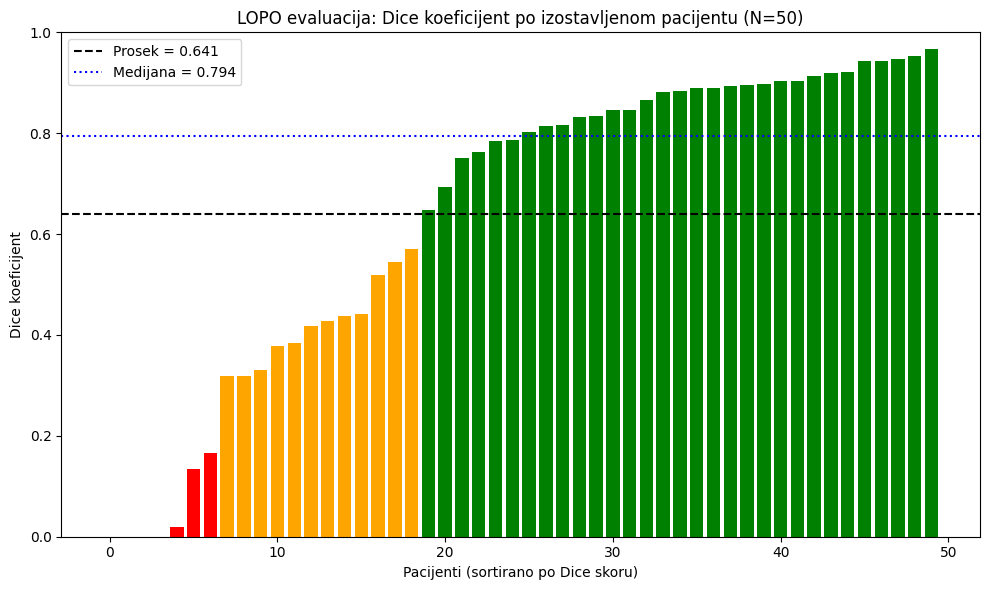

Dice koeficijent po pojedinačnom izostavljenom pacijentu (LOPO), sortirano rastuće. Isprekidana linija označava prosečnu vrednost, tačkasta linija medijanu.


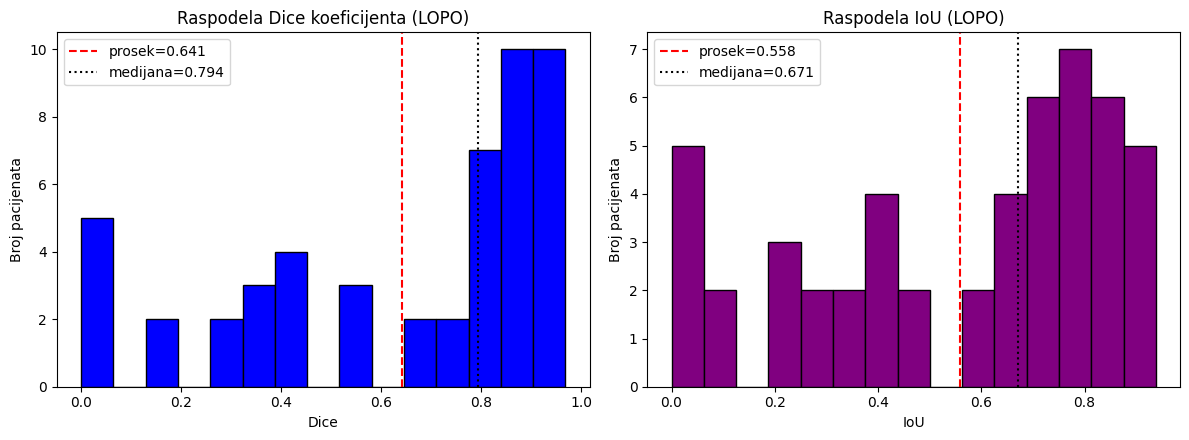

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

sorted_df = results_df.sort_values('dice_raw').reset_index(drop=True)
colors = ['red' if d < 0.3 else 'orange' if d < 0.6 else 'green' for d in sorted_df['dice_raw']]

ax.bar(range(len(sorted_df)), sorted_df['dice_raw'], color=colors)
ax.axhline(results_df['dice_raw'].mean(), color='black', linestyle='--', label=f"Prosek = {results_df['dice_raw'].mean():.3f}")
ax.axhline(results_df['dice_raw'].median(), color='blue', linestyle=':', label=f"Medijana = {results_df['dice_raw'].median():.3f}")
ax.set_title(f"LOPO evaluacija: Dice koeficijent po izostavljenom pacijentu (N={len(results_df)})")
ax.set_xlabel('Pacijenti (sortirano po Dice skoru)')
ax.set_ylabel('Dice koeficijent')
ax.set_ylim(0, 1.0)
ax.legend()

plt.tight_layout()
plt.show()
print("Dice koeficijent po pojedinačnom izostavljenom pacijentu (LOPO), sortirano rastuće. "
      "Isprekidana linija označava prosečnu vrednost, tačkasta linija medijanu.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(results_df['dice_raw'], bins=15, color='blue', edgecolor='black')
axes[0].axvline(results_df['dice_raw'].mean(), color='red', linestyle='--', label=f"prosek={results_df['dice_raw'].mean():.3f}")
axes[0].axvline(results_df['dice_raw'].median(), color='black', linestyle=':', label=f"medijana={results_df['dice_raw'].median():.3f}")
axes[0].set_title('Raspodela Dice koeficijenta (LOPO)')
axes[0].set_xlabel('Dice')
axes[0].set_ylabel('Broj pacijenata')
axes[0].legend()

axes[1].hist(results_df['iou_raw'], bins=15, color='purple', edgecolor='black')
axes[1].axvline(results_df['iou_raw'].mean(), color='red', linestyle='--', label=f"prosek={results_df['iou_raw'].mean():.3f}")
axes[1].axvline(results_df['iou_raw'].median(), color='black', linestyle=':', label=f"medijana={results_df['iou_raw'].median():.3f}")
axes[1].set_title('Raspodela IoU (LOPO)')
axes[1].set_xlabel('IoU')
axes[1].set_ylabel('Broj pacijenata')
axes[1].legend()

plt.tight_layout()
plt.show()

## Los i dobar primer

['53586896', '53586869']


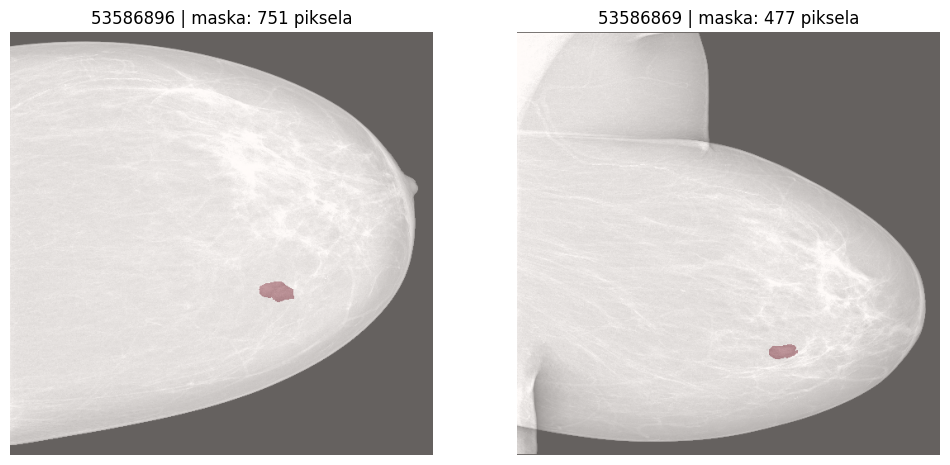

In [27]:
patient_to_inspect = '6ac23356b912ee9b'

patient_case_ids = [cid for cid in case_ids if case_to_patient[cid] == patient_to_inspect]
print(patient_case_ids)

fig, axes = plt.subplots(1, max(len(patient_case_ids), 1), figsize=(6 * max(len(patient_case_ids), 1), 6))
if len(patient_case_ids) == 1:
    axes = [axes]
for ax, cid in zip(axes, patient_case_ids):
    image, mask = image_cache[cid]
    ax.imshow(image, cmap='gray')
    ax.imshow(mask, cmap='Reds', alpha=0.4)
    ax.set_title(f'{cid} | maska: {mask.sum()} piksela')
    ax.axis('off')
plt.show()

['20588680']


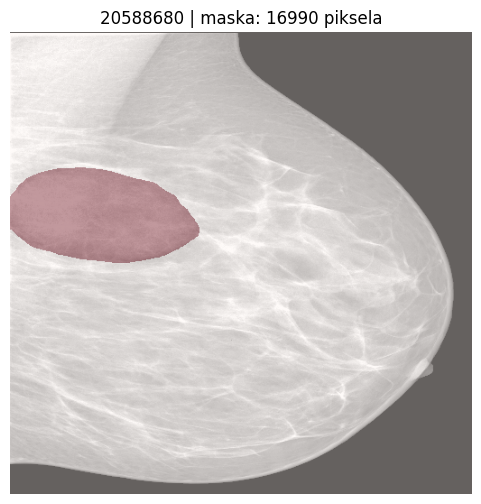

In [28]:
patient_to_inspect = '036aff49b8ac84f0'

patient_case_ids = [cid for cid in case_ids if case_to_patient[cid] == patient_to_inspect]
print(patient_case_ids)

fig, axes = plt.subplots(1, max(len(patient_case_ids), 1), figsize=(6 * max(len(patient_case_ids), 1), 6))
if len(patient_case_ids) == 1:
    axes = [axes]
for ax, cid in zip(axes, patient_case_ids):
    image, mask = image_cache[cid]
    ax.imshow(image, cmap='gray')
    ax.imshow(mask, cmap='Reds', alpha=0.4)
    ax.set_title(f'{cid} | maska: {mask.sum()} piksela')
    ax.axis('off')
plt.show()

## Finalni model

In [31]:
set_seed(SEED)
final_transform = build_augmentation(best_use_elastic)
final_loss_function = build_loss_from_config(best_config)

final_train_loader = DataLoader(
    BreastMassDataset(train_ids_single, image_cache, transform=final_transform),
    batch_size=batch_size, shuffle=True
)

final_model = build_model().to(device)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer, mode='min', factor=0.5, patience=LOPO_SCHEDULER_PATIENCE
)

for epoch in range(80):
    train_loss, train_iou, train_dice = run_epoch(
        final_model, final_train_loader, final_optimizer, device, final_loss_function, train=True
    )
    final_scheduler.step(train_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'epoha {epoch+1:2d} | loss {train_loss:.3f} | dice {train_dice:.3f} | iou {train_iou:.3f}')

test_loss, test_iou, test_dice = run_epoch(
    final_model, val_loader_single, final_optimizer, device, final_loss_function, train=False
)
print(f'\nRezultat na held-out test skupu ({len(val_ids_single)} slika, pacijenti van treninga):')
print(f'  test_loss={test_loss:.3f} | test_dice={test_dice:.3f} | test_iou={test_iou:.3f}')

torch.save(final_model.state_dict(), f'{project_dir}/final_model.pt')
print('\nFinalni model sačuvan: final_model.pt')

epoha  1 | loss 0.901 | dice 0.094 | iou 0.054
epoha 10 | loss 0.744 | dice 0.556 | iou 0.436
epoha 20 | loss 0.568 | dice 0.688 | iou 0.581
epoha 30 | loss 0.447 | dice 0.667 | iou 0.561
epoha 40 | loss 0.290 | dice 0.702 | iou 0.604
epoha 50 | loss 0.217 | dice 0.683 | iou 0.607
epoha 60 | loss 0.155 | dice 0.786 | iou 0.706
epoha 70 | loss 0.131 | dice 0.806 | iou 0.732
epoha 80 | loss 0.115 | dice 0.822 | iou 0.752

Rezultat na held-out test skupu (21 slika, pacijenti van treninga):
  test_loss=0.300 | test_dice=0.644 | test_iou=0.561

Finalni model sačuvan: final_model.pt


## Kvalitativna provera

Kvalitativna provera na held-out test primerima: ['22678787', '24065707', '20587928', '22670094']


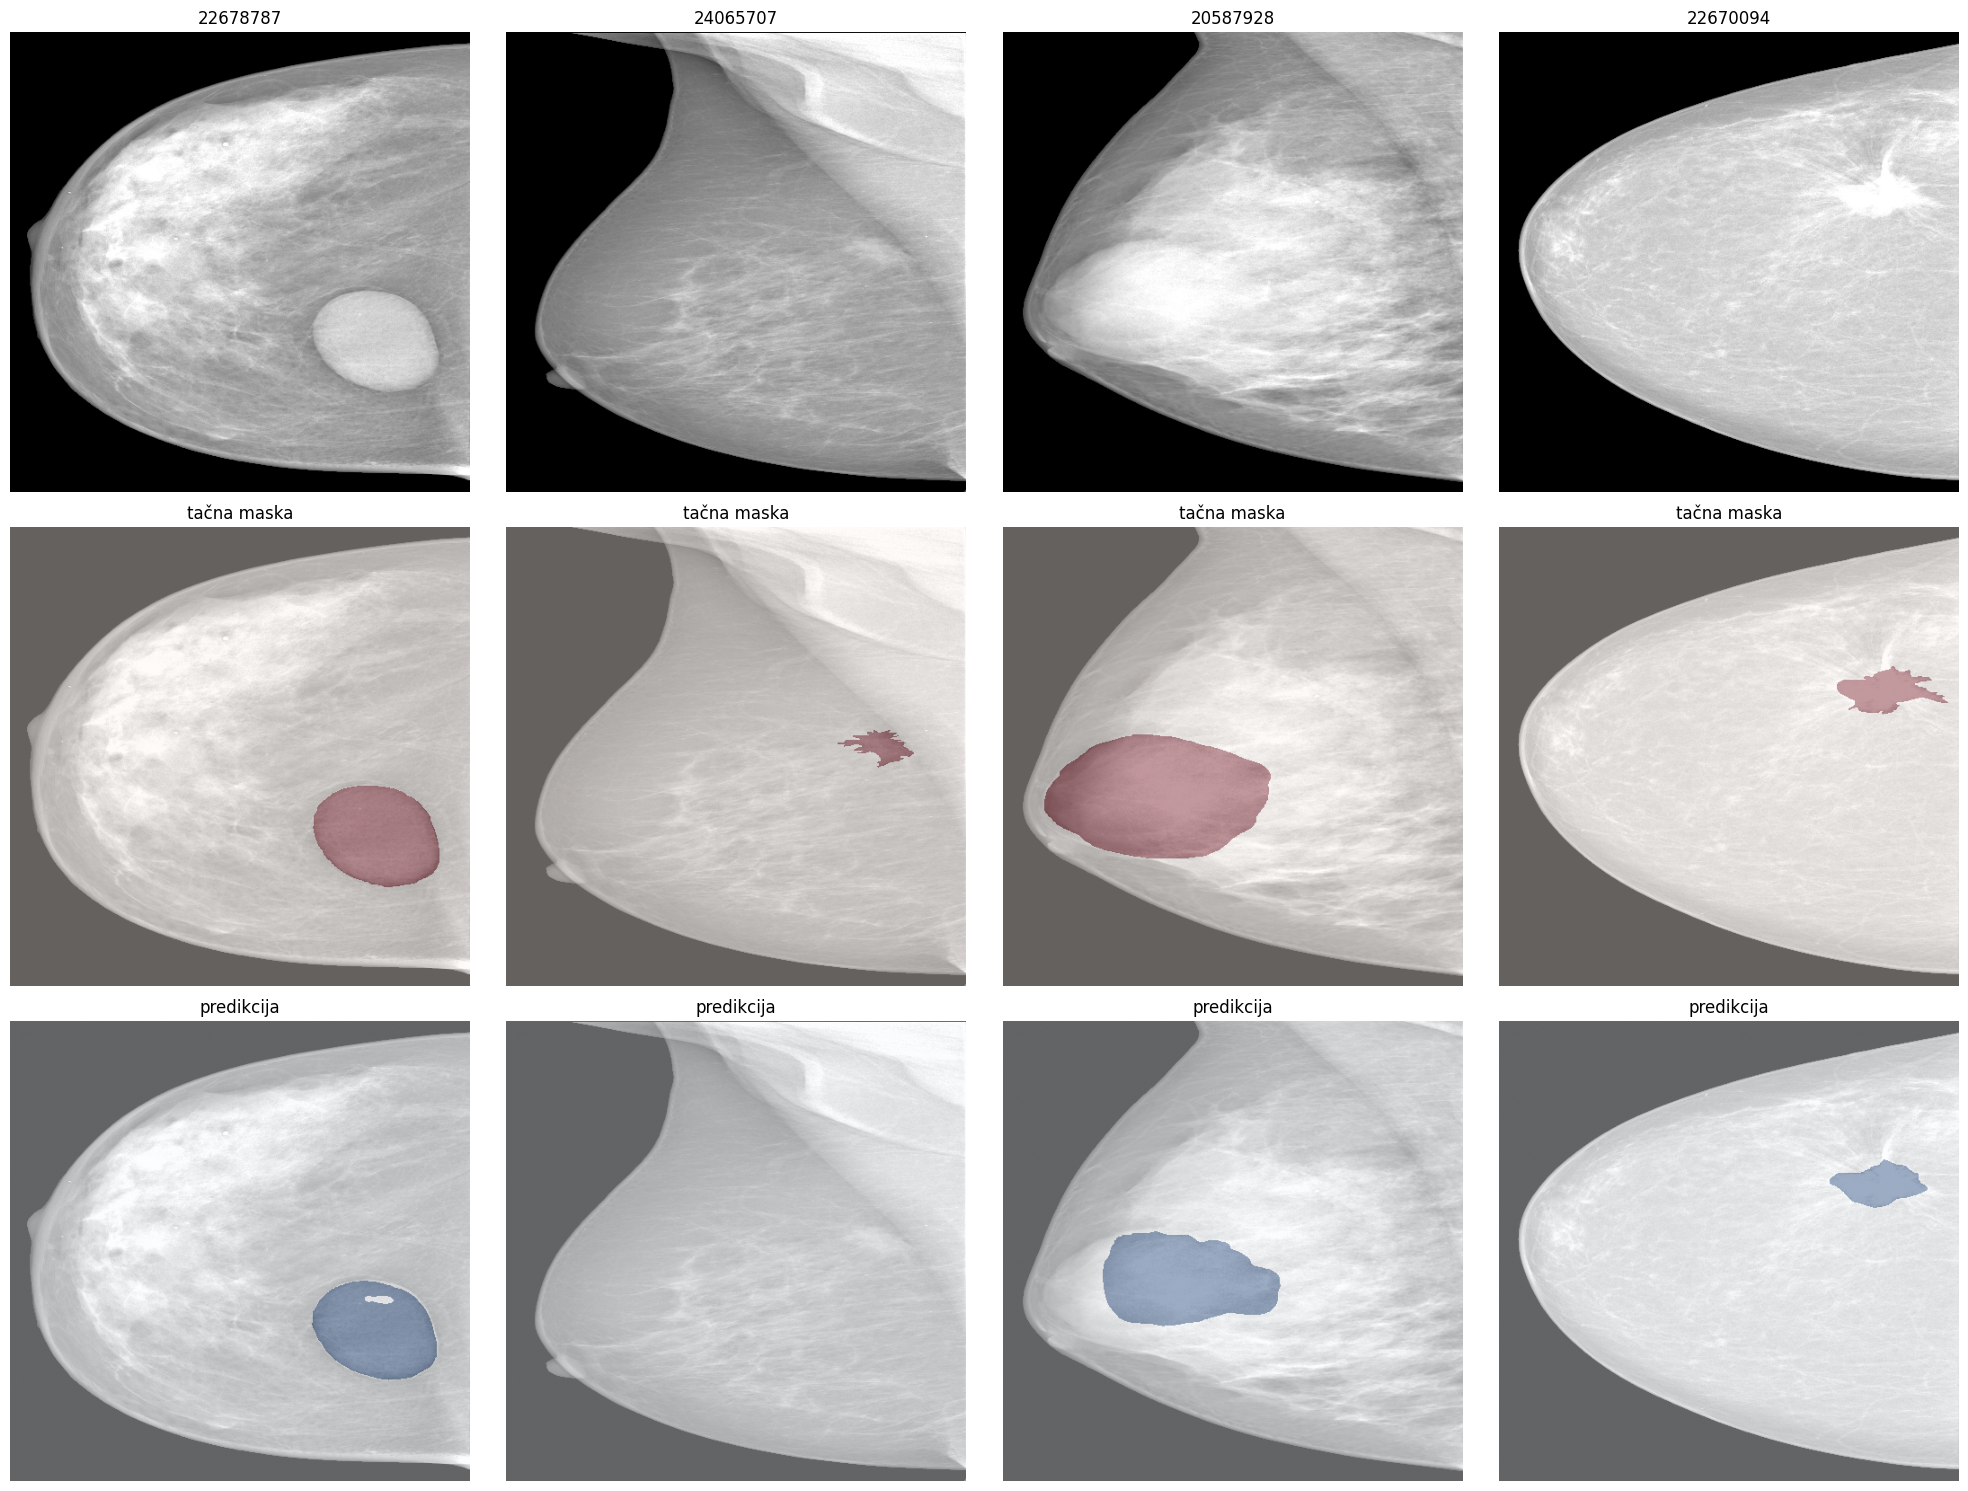

In [32]:
final_model.eval()
sample_ids = random.sample(val_ids_single, min(4, len(val_ids_single)))
print(f'Kvalitativna provera na held-out test primerima: {sample_ids}')

fig, axes = plt.subplots(3, len(sample_ids), figsize=(5 * len(sample_ids), 15))
with torch.no_grad():
    for i, case_id in enumerate(sample_ids):
        image, true_mask = image_cache[case_id]
        image_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).float().to(device)
        pred_mask = (torch.sigmoid(final_model(image_tensor)) > 0.5).cpu().numpy()[0, 0]

        axes[0, i].imshow(image, cmap='gray'); axes[0, i].set_title(case_id); axes[0, i].axis('off')
        axes[1, i].imshow(image, cmap='gray')
        axes[1, i].imshow(true_mask, cmap='Reds', alpha=0.4); axes[1, i].set_title('tačna maska'); axes[1, i].axis('off')
        axes[2, i].imshow(image, cmap='gray')
        axes[2, i].imshow(pred_mask, cmap='Blues', alpha=0.4); axes[2, i].set_title('predikcija'); axes[2, i].axis('off')

plt.tight_layout()
plt.show()